Agrupación de clientes según comportamientos de compra
🎯 Objetivo General:

Simular un conjunto de datos de clientes con características comerciales, aplicar técnicas de machine learning no supervisado para segmentarlos mediante agrupamiento (clustering), y visualizar los resultados para analizar distintos perfiles de cliente. Todo el proyecto debe estar organizado usando clases.



📦 Requisitos:

Utiliza las librerías:

numpy

matplotlib

sklearn.cluster.KMeans

sklearn.preprocessing.StandardScaler

Estructura tu código en tres clases:

SimuladorClientes

ModeloSegmentacionClientes

TestSegmentacionClientes



🧩 Clase SimuladorClientes

Esta clase debe simular los datos de clientes con las siguientes características:

Atributos esperados (por cliente):

Monto gastado: valor entre 100 y 10,000.

Frecuencia de compras: entre 1 y 100.

Categorías preferidas: 3 valores aleatorios entre 1 y 5 (representando número de compras por categoría).

Implementa el método:

def generar_datos(self) -> np.ndarray

Este método debe devolver un array de 200 muestras, cada una con 3 columnas:

Monto gastado

Frecuencia de compras

Total de categorías preferidas (suma de los 3 valores generados)



🧠 Clase ModeloSegmentacionClientes

Esta clase debe encargarse de entrenar el modelo y realizar predicciones.

Atributos:

n_clusters: número de grupos a formar (por defecto: 3).

scaler: instancia de StandardScaler.

modelo: instancia de KMeans.

Métodos requeridos:

entrenar(datos: np.ndarray) -> None:

Escala los datos con StandardScaler.

Ajusta el modelo KMeans.

Guarda los datos escalados como atributo para futuras visualizaciones.

predecir(cliente_nuevo: list) -> int:

Recibe un nuevo cliente (3 características).

Escala sus datos.

Devuelve el número de cluster al que pertenece.



🧪 Clase TestSegmentacionClientes

Clase para integrar y probar todo el sistema. Implementa el método:

def ejecutar(self) -> None

Este método debe:

Crear una instancia de SimuladorClientes y generar los datos.

Instanciar ModeloSegmentacionClientes con 3 clusters.

Entrenar el modelo con los datos simulados.

Mostrar los primeros 5 registros de los datos simulados.

Predecir el cluster para un nuevo cliente con los siguientes datos:

cliente_nuevo = [2000, 10, 12]

(Significa: gastó 2000, compra 10 veces, tiene 12 compras sumadas en sus categorías preferidas).

  6. Mostrar por pantalla el cluster al que pertenece este nuevo cliente.

  7. Incluye una visualización de los datos segmentados usando matplotlib.

Representa los clientes en un gráfico de dispersión donde:

El eje X es el monto gastado.

El eje Y es la frecuencia de compras.

Los puntos se colorean según el cluster al que pertenecen (usa modelo.modelo.labels_ para obtenerlos).

Añade etiquetas, título, y barra de color.



💡 Consejos para el alumno

Usa np.column_stack para combinar varias columnas en un array.

Escalar los datos es fundamental en clustering: sin esto, las variables dominantes como “monto gastado” podrían sesgar los grupos.

Usa KMeans(n_clusters=3, random_state=42) para asegurar reproducibilidad.



🧪 Ejemplo de uso

test = TestSegmentacionClientes()
test.ejecutar()


Salida esperada

Primeros 5 registros de datos simulados:

[[3.80794718e+03 2.40000000e+01 1.00000000e+01]

 [9.51207163e+03 7.50000000e+01 1.30000000e+01]
 
 [7.34674002e+03 7.20000000e+01 9.00000000e+00]
 
 [6.02671899e+03 3.60000000e+01 1.00000000e+01]
 
 [1.64458454e+03 3.80000000e+01 9.00000000e+00]]
 
Modelo entrenado con 3 clusters.
El nuevo cliente pertenece al cluster: 1









Practicar con algoritmos de agrupación de machine learning


# Solucion:

Primeros 5 registros de datos simulados:
[[3.80794718e+03 2.40000000e+01 1.40000000e+01]
 [9.51207163e+03 7.50000000e+01 9.00000000e+00]
 [7.34674002e+03 7.20000000e+01 1.00000000e+01]
 [6.02671899e+03 3.60000000e+01 8.00000000e+00]
 [1.64458454e+03 3.80000000e+01 8.00000000e+00]]
------------------------------
Modelo entrenado con 3 clusters.
------------------------------
Datos nuevo cliente: [2000, 10, 12]
El nuevo cliente pertenece al cluster: 0

Generando gráfico de visualización...


C:\Users\Vaquita\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


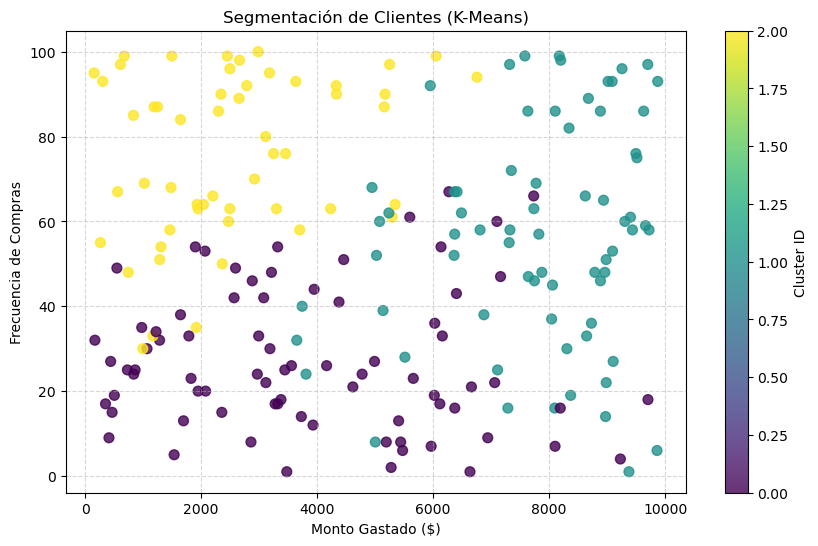

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. Clase SimuladorClientes
# ---------------------------------------------------------
class SimuladorClientes:
    def __init__(self, n=200, seed=42):
        self.n = n
        self.seed = seed

    def generar_datos(self) -> np.ndarray:
        """Genera un array de numpy con datos simulados."""
        np.random.seed(self.seed)
        
        # 1. Monto gastado (100 a 10,000)
        monto = np.random.uniform(100, 10000, self.n)
        
        # 2. Frecuencia de compras (1 a 100)
        frecuencia = np.random.randint(1, 101, self.n)
        
        # 3. Categorías preferidas (Suma de 3 valores entre 1 y 5)
        # Simulamos 3 compras de categorías distintas y las sumamos
        cat1 = np.random.randint(1, 6, self.n)
        cat2 = np.random.randint(1, 6, self.n)
        cat3 = np.random.randint(1, 6, self.n)
        total_categorias = cat1 + cat2 + cat3
        
        # Combinar en una matriz (array) de (200, 3)
        datos = np.column_stack((monto, frecuencia, total_categorias))
        
        return datos

# ---------------------------------------------------------
# 2. Clase ModeloSegmentacionClientes
# ---------------------------------------------------------
class ModeloSegmentacionClientes:
    def __init__(self, n_clusters=3):
        self.n_clusters = n_clusters
        self.scaler = StandardScaler()
        self.modelo = KMeans(n_clusters=self.n_clusters, random_state=42, n_init=10)
        self.datos_escalados = None

    def entrenar(self, datos: np.ndarray) -> None:
        """Entrena el modelo KMeans con datos escalados."""
        # Es FUNDAMENTAL escalar los datos en Clustering.
        # Si no, el 'Monto' (ej. 5000) dominaría sobre 'Categorías' (ej. 10).
        self.datos_escalados = self.scaler.fit_transform(datos)
        
        # Entrenar el modelo
        self.modelo.fit(self.datos_escalados)
        print(f"Modelo entrenado con {self.n_clusters} clusters.")

    def predecir(self, cliente_nuevo: list) -> int:
        """Predice el cluster para un nuevo cliente."""
        # Convertir lista a array 2D
        cliente_array = np.array(cliente_nuevo).reshape(1, -1)
        
        # Escalar con el MISMO scaler usado en el entrenamiento
        cliente_escalado = self.scaler.transform(cliente_array)
        
        # Predecir
        cluster = self.modelo.predict(cliente_escalado)
        return cluster[0]

# ---------------------------------------------------------
# 3. Clase TestSegmentacionClientes
# ---------------------------------------------------------
class TestSegmentacionClientes:
    def ejecutar(self) -> None:
        # A. Generar datos
        simulador = SimuladorClientes()
        datos = simulador.generar_datos()
        
        print("Primeros 5 registros de datos simulados:")
        print(datos[:5])
        print("-" * 30)

        # B. Entrenar modelo
        segmentador = ModeloSegmentacionClientes(n_clusters=3)
        segmentador.entrenar(datos)

        # C. Predicción de nuevo cliente
        # [Monto: 2000, Frecuencia: 10, Categorías: 12]
        cliente_nuevo = [2000, 10, 12]
        cluster_predicho = segmentador.predecir(cliente_nuevo)
        
        print("-" * 30)
        print(f"Datos nuevo cliente: {cliente_nuevo}")
        print(f"El nuevo cliente pertenece al cluster: {cluster_predicho}")
        
        # D. Visualización
        self.visualizar_clusters(datos, segmentador.modelo.labels_)

    def visualizar_clusters(self, datos, labels):
        """Genera un gráfico de dispersión para ver los grupos."""
        plt.figure(figsize=(10, 6))
        
        # Eje X: Monto (columna 0), Eje Y: Frecuencia (columna 1)
        scatter = plt.scatter(datos[:, 0], datos[:, 1], c=labels, cmap='viridis', s=50, alpha=0.8)
        
        plt.title('Segmentación de Clientes (K-Means)')
        plt.xlabel('Monto Gastado ($)')
        plt.ylabel('Frecuencia de Compras')
        plt.colorbar(scatter, label='Cluster ID')
        plt.grid(True, linestyle='--', alpha=0.5)
        
        print("\nGenerando gráfico de visualización...")
        plt.show()

# ---------------------------------------------------------
# Ejecución
# ---------------------------------------------------------
if __name__ == "__main__":
    test = TestSegmentacionClientes()
    test.ejecutar()

Casos de prueba

Suspenso: 0, Aprobado: 3 de 3 pruebas

test_entrenamiento_modelo

test_formato_datos

test_prediccion_valida